In [1]:
import pandas as pd
import numpy as np

In [3]:
import xlrd

In [5]:
df=pd.read_csv('GraduateEmploymentSurveyNTUNUSSITSMUSUSSSUTD.csv', encoding='latin-1')

In [7]:
df.head(3)

,year,university,school,degree,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,97.4,96.1,3701,3200,3727,3350,2900,4000
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),97.1,95.7,2850,2700,2938,2700,2700,2900
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),90.9,85.7,3053,3000,3214,3000,2700,3500


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       1262 non-null   int64 
 1   university                 1262 non-null   object
 2   school                     1262 non-null   object
 3   degree                     1262 non-null   object
 4   employment_rate_overall    1262 non-null   object
 5   employment_rate_ft_perm    1262 non-null   object
 6   basic_monthly_mean         1262 non-null   object
 7   basic_monthly_median       1262 non-null   object
 8   gross_monthly_mean         1262 non-null   object
 9   gross_monthly_median       1262 non-null   object
 10  gross_mthly_25_percentile  1262 non-null   object
 11  gross_mthly_75_percentile  1262 non-null   object
dtypes: int64(1), object(11)
memory usage: 118.4+ KB


In [11]:
df.shape

(1262, 12)

In [13]:
df['university'].unique()

array(['Nanyang Technological University',
       'National University of Singapore',
       'Singapore Management University',
       'Singapore Institute of Technology',
       'Singapore University of Technology and Design',
       'Singapore University of Social Sciences'], dtype=object)

In [16]:
replace_schoolnames = {
   'Nanyang Technological University':'NTU',
       'National University of Singapore':'NUS',
       'Singapore Management University':'SMU',
       'Singapore Institute of Technology':'SIT',
       'Singapore University of Technology and Design':'SUTD',
       'Singapore University of Social Sciences':'SUSS'
}

df.replace(to_replace=replace_schoolnames, inplace=True)

In [18]:
df['university'].unique() #checking

array(['NTU', 'NUS', 'SMU', 'SIT', 'SUTD', 'SUSS'], dtype=object)

In [119]:
def clean_na(text):
    '''This is how the the thinggy works '''
    try:
        return text.replace("na", np.nan)
    except AttributeError:
        # This will handle the NaN of the missing data
        return text

df= df.apply(clean_na) #how to check

In [120]:
help(clean_na)

Help on function clean_na in module __main__:

clean_na(text)
    This is how the the thinggy works



In [110]:
np.nansum([50,np.nan,100])

np.float64(150.0)

In [22]:
new_type_info = {'basic_monthly_median': 'float'}
df = df.astype(new_type_info)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       1262 non-null   int64  
 1   university                 1262 non-null   object 
 2   school                     1230 non-null   object 
 3   degree                     1262 non-null   object 
 4   employment_rate_overall    1170 non-null   object 
 5   employment_rate_ft_perm    1170 non-null   object 
 6   basic_monthly_mean         1170 non-null   object 
 7   basic_monthly_median       1170 non-null   float64
 8   gross_monthly_mean         1170 non-null   object 
 9   gross_monthly_median       1170 non-null   object 
 10  gross_mthly_25_percentile  1170 non-null   object 
 11  gross_mthly_75_percentile  1170 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 118.4+ KB


# wrong answer

In [54]:
columns_to_keep = ['year', 'university','basic_monthly_median']
df = df[columns_to_keep]
df.head()

,year,university,basic_monthly_median
0,2013,NTU,3200.0
1,2013,NTU,2700.0
2,2013,NTU,3000.0
3,2013,NTU,3400.0
4,2013,NTU,3500.0


In [55]:
df.head()

,year,university,basic_monthly_median
0,2013,NTU,3200.0
1,2013,NTU,2700.0
2,2013,NTU,3000.0
3,2013,NTU,3400.0
4,2013,NTU,3500.0


In [89]:
#selected_df=df.loc[mask, ["year", "university","basic_monthly_median"]]   
#print(selected_df.shape)
df.groupby(by=["year", "university"])[["basic_monthly_median"]].agg([np.count_nonzero, np.min, np.max, np.mean, np.std])

C:\Users\lmr20\AppData\Local\Temp\ipykernel_38324\2888722413.py:3: FutureWarning: The provided callable <function min at 0x0000016ED901C4A0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby(by=["year", "university"])[["basic_monthly_median"]].agg([np.count_nonzero, np.min, np.max, np.mean, np.std])
C:\Users\lmr20\AppData\Local\Temp\ipykernel_38324\2888722413.py:3: FutureWarning: The provided callable <function max at 0x0000016ED901C360> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby(by=["year", "university"])[["basic_monthly_median"]].agg([np.count_nonzero, np.min, np.max, np.mean, np.std])
C:\Users\lmr20\AppData\Local\Temp\ipykernel_38324\2888722413.py:3: FutureWarning: The provided callable <function mean at 0x0000016E

basic_monthly_median                                         
                       count_nonzero     min     max         mean         std
year university                                                              
2013 NTU                          34  2500.0  3500.0  3009.562500  214.472336
     NUS                          39  2650.0  4800.0  3119.030303  473.869476
     SMU                          12  2800.0  5000.0  3493.750000  710.963255
2014 NTU                          34  2600.0  3700.0  3074.242424  212.820058
     NUS                          39  2550.0  5000.0  3265.647059  505.622322
     SIT                          24  2400.0  3355.0  2899.583333  270.446156
     SMU                          12  2850.0  4900.0  3624.166667  653.615238
2015 NTU                          39  2800.0  4184.0  3153.939394  275.998748
     NUS                          40  2850.0  4600.0  3389.055556  427.336531
     SIT                          28  2300.0  3400.0  2958.800000  264.434459
     SMU                          12  2900.0  4766.0  3630.500000  575.909794
     SUTD                          4  3450.0  3700.0  3589.333333  127.441490
2016 NTU                          39  2400.0  4000.0  3231.323529  282.366377
     NUS                          38  2800.0  4775.0  3391.911765  445.547016
     SIT                          28  2250.0  4200.0  3122.692308  406.010420
     SMU                          12  3000.0  4950.0  3713.916667  597.020246
     SUTD                          4  3500.0  4000.0  3700.000000  264.575131
2017 NTU                          43  2800.0  4750.0  3313.057143  338.092308
     NUS                          43  2025.0  5000.0  3445.486486  524.884518
     SIT                          30  2300.0  3800.0  3102.678571  342.873160
     SMU                          12  3000.0  5450.0  3849.500000  675.129819
     SUTD                          4  3600.0  4000.0  3800.000000  200.000000
2018 NTU                          44  2800.0  4450.0  3410.594595  322.757689
     NUS                          41  1750.0  5000.0  3531.181818  596.037302
     SIT                          33  2530.0  4000.0  3274.687500  377.406210
     SMU                          12  3000.0  4750.0  3850.000000  565.685425
     SUSS                          3  2850.0  3400.0  3083.333333  284.312035
     SUTD                          4  3700.0  4300.0  3925.000000  262.995564
2019 NTU                          45  3000.0  4833.0  3526.921053  412.544208
     NUS                          39  3000.0  5000.0  3736.527778  570.828745
     SIT                          36  2350.0  4400.0  3396.709677  445.578515
     SMU                          12  3000.0  5000.0  3963.833333  634.741155
     SUSS                          4  3000.0  3400.0  3100.000000  200.000000
     SUTD                          4  3800.0  4400.0  3999.250000  271.174452
2020 NTU                          40  2800.0  5200.0  3638.400000  471.346288
     NUS                          39  3000.0  5350.0  3895.384615  609.243907
     SIT                          37  2475.0  5000.0  3487.405405  507.024186
     SMU                          12  3050.0  5000.0  4005.833333  626.265386
     SUSS                          7  2750.0  3500.0  3059.000000  236.185661
     SUTD                          4  3800.0  4500.0  4012.500000  332.603367
2021 NTU                          39  3000.0  6300.0  3765.589744  609.553880
     NUS                          39  2958.0  5800.0  3967.210526  656.449177
     SIT                          33  2500.0  5000.0  3556.060606  499.336681
     SMU                          12  3400.0  5600.0  4369.416667  783.332909
     SUSS                          8  3000.0  3800.0  3328.750000  258.093975
     SUTD                          4  3801.0  4800.0  4275.250000  457.001368
2022 NTU                          41  3100.0  6000.0  4110.439024  689.419141
     NUS                          40  3350.0  6500.0  4404.842105  827.762844
     SIT                          35  

In [111]:
grp=df.groupby(by=["year", "university"])[["basic_monthly_median"]].agg([np.count_nonzero, np.min, np.max, np.mean, np.std])
grp.tail(10)

C:\Users\lmr20\AppData\Local\Temp\ipykernel_38324\2713772688.py:1: FutureWarning: The provided callable <function min at 0x0000016ED901C4A0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  grp=df.groupby(by=["year", "university"])[["basic_monthly_median"]].agg([np.count_nonzero, np.min, np.max, np.mean, np.std])
C:\Users\lmr20\AppData\Local\Temp\ipykernel_38324\2713772688.py:1: FutureWarning: The provided callable <function max at 0x0000016ED901C360> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  grp=df.groupby(by=["year", "university"])[["basic_monthly_median"]].agg([np.count_nonzero, np.min, np.max, np.mean, np.std])
C:\Users\lmr20\AppData\Local\Temp\ipykernel_38324\2713772688.py:1: FutureWarning: The provided callable <function mean at 0x

basic_monthly_median                                         
                       count_nonzero     min     max         mean         std
year university                                                              
2021 SIT                          33  2500.0  5000.0  3556.060606  499.336681
     SMU                          12  3400.0  5600.0  4369.416667  783.332909
     SUSS                          8  3000.0  3800.0  3328.750000  258.093975
     SUTD                          4  3801.0  4800.0  4275.250000  457.001368
2022 NTU                          41  3100.0  6000.0  4110.439024  689.419141
     NUS                          40  3350.0  6500.0  4404.842105  827.762844
     SIT                          35  2450.0  5500.0  3914.085714  593.000713
     SMU                          12  3800.0  6338.0  4711.000000  860.401281
     SUSS                          9  3100.0  4500.0  3670.625000  415.300558
     SUTD                          4  4100.0  5000.0  4437.500000  415.080314

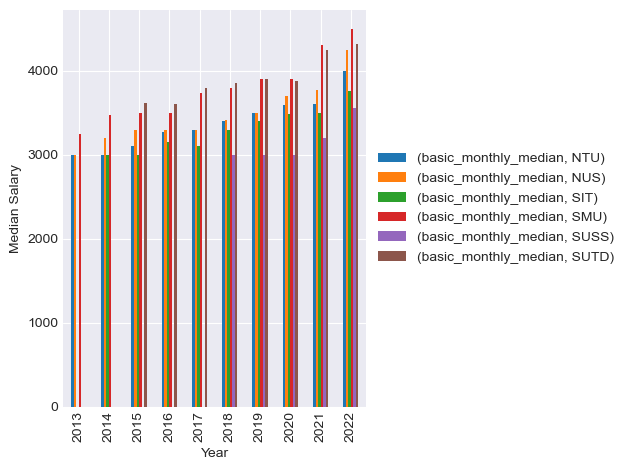

In [106]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")

grp = df.groupby(by=["year", "university"])[["basic_monthly_median"]]
grp.median().unstack().plot(kind='bar');

plt.ylabel('Median Salary')
plt.xlabel('Year')

plt.legend(title='', bbox_to_anchor=(1, 0.5), loc='center left')

plt.tight_layout()
plt.show()
